# MileStone : 2 (week 2-4)
 ### CORE ANALYSIS & VISUALIZATION DESIGN 

1. Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_global_weather.csv")
df["last_updated"] = pd.to_datetime(df["last_updated"])


2. Statistical Analysis: Distributions

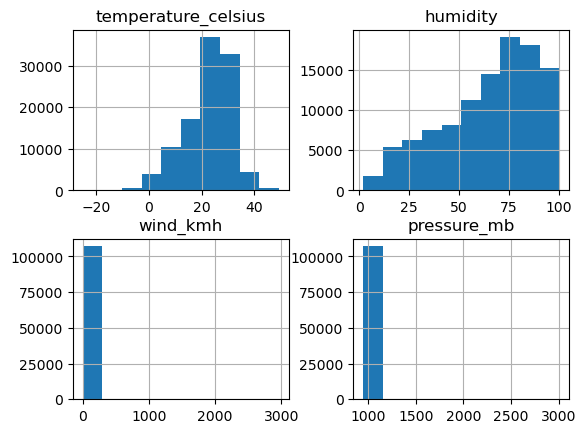

In [5]:
df[["temperature_celsius", "humidity", "wind_kmh", "pressure_mb"]].hist()
plt.show()


3.Correlation Analysis

In [7]:
corr = df[["temperature_celsius", "humidity", "wind_kmh", "pressure_mb", "uv_index"]].corr()
print(corr)



                     temperature_celsius  humidity  wind_kmh  pressure_mb  \
temperature_celsius             1.000000 -0.345984  0.079382    -0.308035   
humidity                       -0.345984  1.000000 -0.066837     0.011678   
wind_kmh                        0.079382 -0.066837  1.000000    -0.075704   
pressure_mb                    -0.308035  0.011678 -0.075704     1.000000   
uv_index                        0.480338 -0.566849  0.052985    -0.063162   

                     uv_index  
temperature_celsius  0.480338  
humidity            -0.566849  
wind_kmh             0.052985  
pressure_mb         -0.063162  
uv_index             1.000000  


4. Seasonal Patterns & Trends

    month  temperature_celsius   humidity
0       1            17.393976  67.129038
1       2            17.426079  66.104086
2       3            20.096351  64.144347
3       4            21.965888  63.027350
4       5            23.961209  62.313995
5       6            25.705650  60.891873
6       7            26.020309  62.319969
7       8            25.749148  62.942841
8       9            24.249988  66.219004
9      10            21.603025  68.864390
10     11            19.312265  69.733784
11     12            17.752100  65.780811


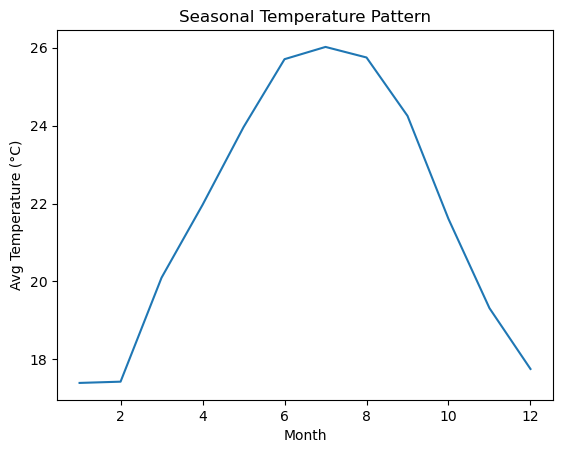

In [8]:
df["month"] = df["last_updated"].dt.month
seasonal = df.groupby("month").agg({"temperature_celsius":"mean","humidity":"mean"}).reset_index()
print(seasonal)

plt.plot(seasonal["month"], seasonal["temperature_celsius"])
plt.xlabel("Month")
plt.ylabel("Avg Temperature (°C)")
plt.title("Seasonal Temperature Pattern")
plt.show()


6. Identify Extreme Events (Heatwaves, Storms, etc.)

In [10]:
df["extreme_event"] = "Normal"
df.loc[df["temperature_celsius"] > 45, "extreme_event"] = "Heatwave"
df.loc[df["wind_kmh"] > 120, "extreme_event"] = "Storm"
df.loc[df["precip_mm"] > 200, "extreme_event"] = "Heavy Rain"
df.loc[df["uv_index"] > 10, "extreme_event"] = "Extreme UV"

df[df["extreme_event"] != "Normal"].groupby("extreme_event").size()


extreme_event
Extreme UV    6117
Heatwave        59
Storm            5
dtype: int64

7. Regional Comparisons

In [11]:
# Average weather per region
region_compare = df.groupby("country").agg({
    "temperature_celsius":"mean",
    "humidity":"mean",
    "wind_kmh":"mean",
    "pressure_mb":"mean",
}).reset_index()

region_compare.head()

,country,temperature_celsius,humidity,wind_kmh,pressure_mb
0,Afghanistan,21.559790,23.392015,9.389374,1009.328494
1,Albania,22.359246,51.637024,9.172654,1015.822142
2,Algeria,23.036970,59.590909,12.750362,1017.290909
3,Andorra,12.020871,59.446461,8.358345,1017.989111
4,Angola,26.147106,73.279492,9.508834,1013.148820


8. Visualization Selections (Examples Required in PR/Report)

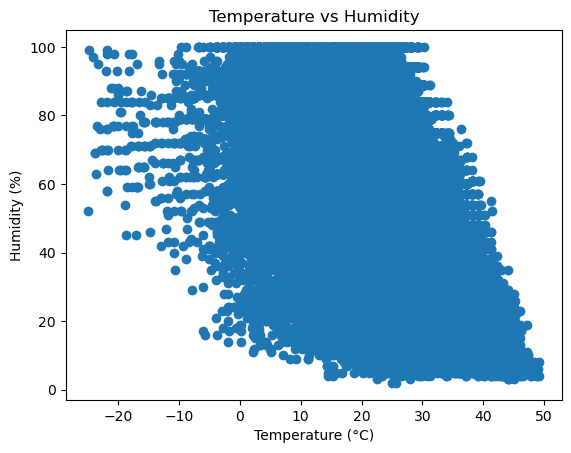

In [12]:
# Scatter plot for temperature vs humidity
plt.scatter(df["temperature_celsius"], df["humidity"])
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.title("Temperature vs Humidity")
plt.show()

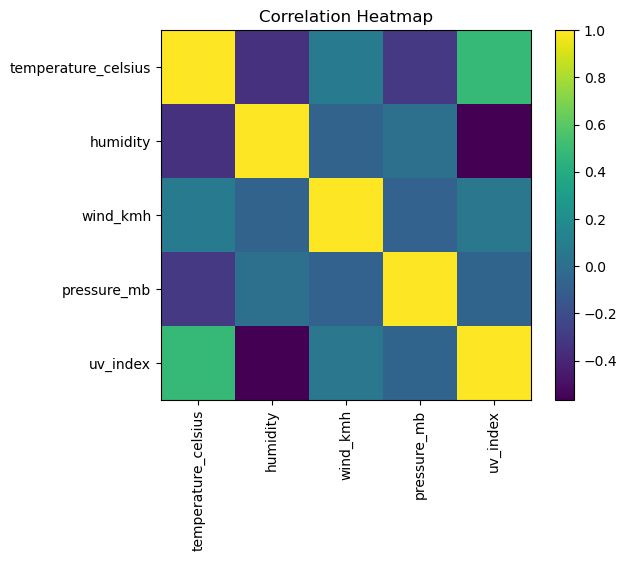

In [13]:
# Heatmap for correlation
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

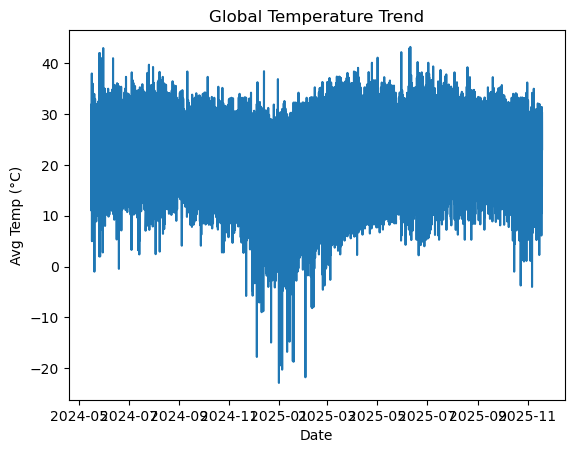

In [14]:
 # Line chart for trend
trend = df.groupby("last_updated").agg({"temperature_celsius":"mean"}).reset_index()
plt.plot(trend["last_updated"], trend["temperature_celsius"])
plt.xlabel("Date")
plt.ylabel("Avg Temp (°C)")
plt.title("Global Temperature Trend")
plt.show()

9. Mark Extreme Events on a Chart

In [16]:
# Recreate extreme temperature records
extreme_temp = df[(df["temperature_celsius"] > 45) | (df["temperature_celsius"] < -20)]

print("Extreme temperature events:", extreme_temp.shape[0])
extreme_temp.head()



Extreme temperature events: 185


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,moonset,moon_phase,moon_illumination,wind_kmh,temperature_celsius_calc,temp_norm,humidity_norm,wind_norm,month,extreme_event
3010,Kuwait,Kuwait City,29.37,47.96,Asia/Kuwait,1717076700,2024-05-30 16:45:00,45.611111,114.1,Sunny,...,11:15 AM,Last Quarter,58,6.920162,45.611111,0.951274,0.061224,0.001142,5,Heatwave
3205,Kuwait,Kuwait City,29.37,47.96,Asia/Kuwait,1717164900,2024-05-31 17:15:00,45.722222,114.3,Sunny,...,12:19 PM,Waning Crescent,47,3.540548,45.722222,0.952774,0.071429,0.000000,5,Heatwave
4180,Kuwait,Kuwait City,29.37,47.96,Asia/Kuwait,1717596900,2024-06-05 17:15:00,45.222222,113.4,Sunny,...,05:53 PM,Waning Crescent,3,29.933724,45.222222,0.946027,0.020408,0.008918,6,Heatwave
4373,Kuwait,Kuwait City,29.37,47.96,Asia/Kuwait,1717682400,2024-06-06 17:00:00,45.888889,114.6,Sunny,...,07:00 PM,New Moon,0,9.012304,45.888889,0.955022,0.020408,0.001849,6,Heatwave
4568,Kuwait,Kuwait City,29.37,47.96,Asia/Kuwait,1717768800,2024-06-07 17:00:00,46.611111,115.9,Partly cloudy,...,08:03 PM,Waxing Crescent,0,16.898070,46.611111,0.964768,0.020408,0.004513,6,Heatwave
